# Principal component analysis 
PCA (Principal component analysis) is a powerful tool often used in dimensionality reduction.

We will today use PCA to reduce the dimensionality of the Iris dataset from $X \in \mathbb{R}^4$ to $X' \in \mathbb{R}^2$.

In [1]:
import numpy as np
import sklearn as sk
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd

# plot data and fit (2d only)
def plot_fit(X, y, clf):
    """
    X = samples
    y = Ground truth
    clf = trained model
    """
    h = .02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot
    Z = Z.reshape(xx.shape)
    fig = plt.figure(1, figsize=(8, 6))
    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)

    # Plot also the training points
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors= "black")
    plt.xlabel('Sepal length')
    plt.ylabel('Sepal width')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xticks(())
    plt.yticks(())

In [2]:
# import some data to play with
iris = sk.datasets.load_iris()
iris_df = pd.DataFrame(iris.data, columns = iris.feature_names)
display(iris_df)
X = StandardScaler().fit_transform(iris_df)
target = iris.target
print ("Number of samples ::", X.shape[0])
print("Number of features ::", X.shape[1])

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


Number of samples :: 150
Number of features :: 4


## Dimensionality reduction.
To use PCA in practice, simply use the following function:

```{Python}
pca = PCA(n_components = n )
principalComponents = pca.fit_transform(data_to_transform)

```
Find the documentation here: [sklearn PCA documentation](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)

In [3]:
# Apply PCA with 2 components
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(X)

print(f"Original shape: {X.shape}")
print(f"PCA shape: {principalComponents.shape}")

Original shape: (150, 4)
PCA shape: (150, 2)


Plot the principal components and compare them to X:

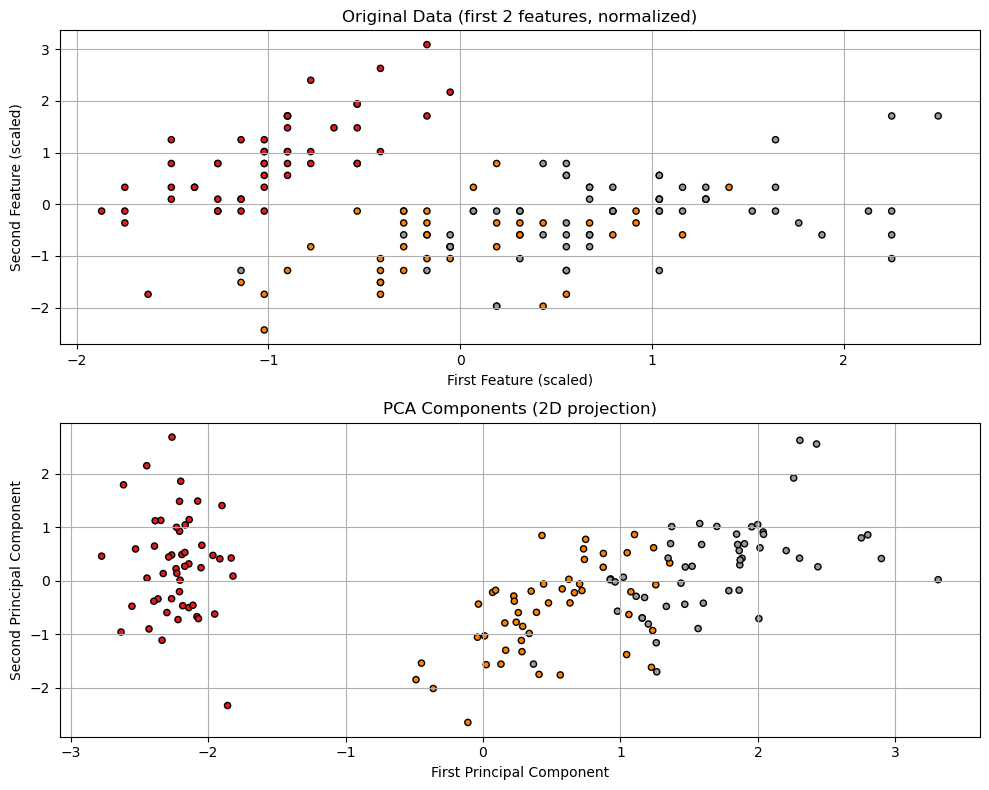

In [4]:
# Plot scaled data vs PCA components
fig = plt.figure(1, figsize=(10, 8))

# Plot scaled version (first 2 features)
ax = plt.subplot(211)
x, y = X[:, 0], X[:, 1]
plt.scatter(x, y, c=target, cmap=plt.cm.Set1, edgecolor='black', s=20)
plt.xlabel('First Feature (scaled)')
plt.ylabel('Second Feature (scaled)')
plt.title('Original Data (first 2 features, normalized)')
plt.grid()

# Plot principal components
plt.subplot(212)
x1, y1 = principalComponents[:, 0], principalComponents[:, 1]
plt.scatter(x1, y1, c=target, cmap=plt.cm.Set1, edgecolor='black', s=20)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('PCA Components (2D projection)')
plt.grid()
plt.tight_layout()
plt.show()

## Explained Variance
The explained variance tells you how much information (variance) can be attributed to each of the principal components. 

By using the attribute `explained_variance_ratio_`, you can see that the first principal component explains 72.77% of the variance and the second principal component explains 23.03% of the variance.

In [5]:
print(pca.explained_variance_ratio_)

print(sum(pca.explained_variance_ratio_))

[0.72962445 0.22850762]
0.9581320720000164


So, in total our PCA has now expressed 96% of the variance of the dataset.
We can use these new components to attempt to fit an SVM like we did in the previous exercise. The lower dimensional data should retain most of the information in the original data and therefore should compete close to on par with a classifier trained on all features.

## Exercises
### 1) SVM
Apply an SVM to the principal components. How does it perform compared to using only two features per sample?

## 2) Three principal components
Attempt with three principal components. 
How much of the variance of the data do these express? 

Again, make a 3D plot where each point is colored respective to the predicted class from your SVM.

## 3) Best accuracy
Compare all the different SVM's we have trained. What is the best accuracy you can acheive?. You are also allowed to use different kernels!

## 4) Grid search
Attempt to perform a grid search with the function provided by `sklearn`.
The `gridsearch` function will try a lot of different combinations of parameters for your SVM so you don't have to.
```{Python}
from sklearn.model_selection import GridSearchCV
import numpy as np
    
c = np.logspace(start = -15, stop = 1000, base = 1.02)
param_grid = {'C': c}

grid = GridSearchCV(clf, param_grid = param_grid, cv = 3, n_jobs = -1, scoring = 'accuracy')
grid.fit(X_train, y_train)
```
[GridSearchCV documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)


Are you able to get a better fit?

Exercise 1: SVM on 2 PCA components
Train accuracy: 0.925
Test accuracy: 0.900


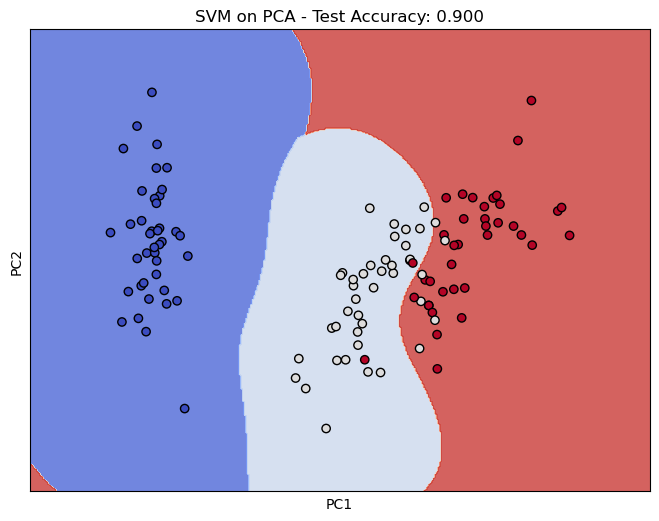


Comparison:
2 original features: 0.900
2 PCA components:    0.900


In [6]:
# Exercise 1: SVM on 2 PCA components
from sklearn import svm

# Split data
X_train_pca, X_test_pca, y_train, y_test = train_test_split(principalComponents, target, test_size=0.2, random_state=42)

# Train SVM on PCA components
clf_pca = svm.SVC(kernel='rbf', gamma=0.7, C=1.0)
clf_pca.fit(X_train_pca, y_train)

print("Exercise 1: SVM on 2 PCA components")
print(f"Train accuracy: {clf_pca.score(X_train_pca, y_train):.3f}")
print(f"Test accuracy: {clf_pca.score(X_test_pca, y_test):.3f}")

# Visualize
plot_fit(X_train_pca, y_train, clf_pca)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'SVM on PCA - Test Accuracy: {clf_pca.score(X_test_pca, y_test):.3f}')
plt.show()

# Compare with original 2 features
X_2feat = X[:, :2]
X_train_2feat, X_test_2feat, y_train_2f, y_test_2f = train_test_split(X_2feat, target, test_size=0.2, random_state=42)
clf_2feat = svm.SVC(kernel='rbf', gamma=0.7, C=1.0)
clf_2feat.fit(X_train_2feat, y_train_2f)

print(f"\nComparison:")
print(f"2 original features: {clf_2feat.score(X_test_2feat, y_test_2f):.3f}")
print(f"2 PCA components:    {clf_pca.score(X_test_pca, y_test):.3f}")


Exercise 2: Three principal components
Explained variance ratio: [0.72962445 0.22850762 0.03668922]
Total variance explained: 0.9948 (99.48%)
Train accuracy: 0.975
Test accuracy: 1.000


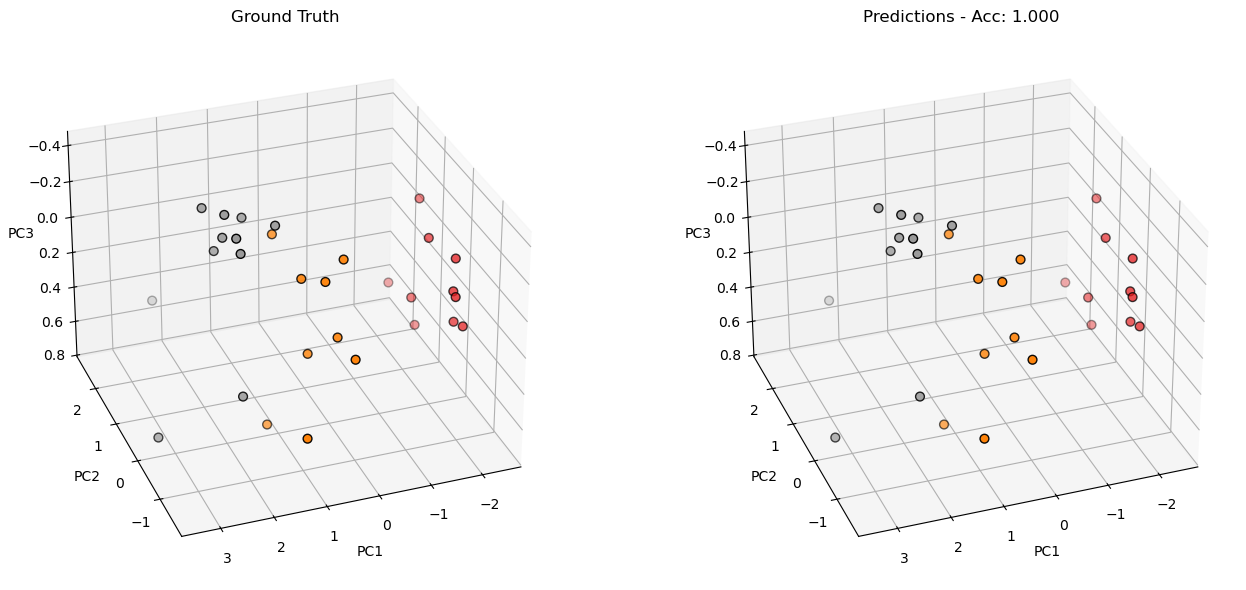

In [7]:
# Exercise 2: Three principal components
pca_3d = PCA(n_components=3)
principalComponents_3d = pca_3d.fit_transform(X)

print("\nExercise 2: Three principal components")
print(f"Explained variance ratio: {pca_3d.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca_3d.explained_variance_ratio_):.4f} ({sum(pca_3d.explained_variance_ratio_)*100:.2f}%)")

# Split and train
X_train_3d, X_test_3d, y_train_3d, y_test_3d = train_test_split(principalComponents_3d, target, test_size=0.2, random_state=42)
clf_3d = svm.SVC(kernel='rbf', gamma=0.7, C=1.0)
clf_3d.fit(X_train_3d, y_train_3d)

print(f"Train accuracy: {clf_3d.score(X_train_3d, y_train_3d):.3f}")
print(f"Test accuracy: {clf_3d.score(X_test_3d, y_test_3d):.3f}")

# 3D visualization
y_pred_3d = clf_3d.predict(X_test_3d)

fig = plt.figure(figsize=(14, 6))

# Ground truth
ax1 = fig.add_subplot(121, projection='3d', elev=-150, azim=110)
ax1.scatter(X_test_3d[:, 0], X_test_3d[:, 1], X_test_3d[:, 2], c=y_test_3d, cmap=plt.cm.Set1, edgecolors='black', s=40)
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_zlabel('PC3')
ax1.set_title('Ground Truth')

# Predictions
ax2 = fig.add_subplot(122, projection='3d', elev=-150, azim=110)
ax2.scatter(X_test_3d[:, 0], X_test_3d[:, 1], X_test_3d[:, 2], c=y_pred_3d, cmap=plt.cm.Set1, edgecolors='black', s=40)
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_zlabel('PC3')
ax2.set_title(f'Predictions - Acc: {clf_3d.score(X_test_3d, y_test_3d):.3f}')

plt.tight_layout()
plt.show()

In [8]:
# Exercise 3: Best accuracy comparison
print("\n" + "="*60)
print("Exercise 3: Best Accuracy Comparison")
print("="*60)

# All 4 features
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X, target, test_size=0.2, random_state=42)

# Try different configurations
results = {}

# 2 original features
clf_2feat = svm.SVC(kernel='rbf', gamma=0.7, C=1.0)
clf_2feat.fit(X_train_2feat, y_train_2f)
results['2 original features (RBF)'] = clf_2feat.score(X_test_2feat, y_test_2f)

# 2 PCA components
results['2 PCA components (RBF)'] = clf_pca.score(X_test_pca, y_test)

# 3 PCA components
results['3 PCA components (RBF)'] = clf_3d.score(X_test_3d, y_test_3d)

# All 4 features with RBF
clf_full_rbf = svm.SVC(kernel='rbf', gamma=0.7, C=1.0)
clf_full_rbf.fit(X_train_full, y_train_full)
results['All 4 features (RBF)'] = clf_full_rbf.score(X_test_full, y_test_full)

# All 4 features with Linear
clf_full_linear = svm.SVC(kernel='linear', C=1.0)
clf_full_linear.fit(X_train_full, y_train_full)
results['All 4 features (Linear)'] = clf_full_linear.score(X_test_full, y_test_full)

# All 4 features with Polynomial
clf_full_poly = svm.SVC(kernel='poly', degree=3, C=1.0)
clf_full_poly.fit(X_train_full, y_train_full)
results['All 4 features (Poly)'] = clf_full_poly.score(X_test_full, y_test_full)

# Print results sorted by accuracy
for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{name:35s}: {acc:.3f}")

print("="*60)
best_model = max(results.items(), key=lambda x: x[1])
print(f"Best model: {best_model[0]} with {best_model[1]:.3f} accuracy")
print("="*60)


Exercise 3: Best Accuracy Comparison
3 PCA components (RBF)             : 1.000
All 4 features (RBF)               : 1.000
All 4 features (Linear)            : 0.967
All 4 features (Poly)              : 0.967
2 original features (RBF)          : 0.900
2 PCA components (RBF)             : 0.900
Best model: 3 PCA components (RBF) with 1.000 accuracy



Exercise 4: Grid Search for optimal parameters
This may take a moment...
Fitting 5 folds for each of 300 candidates, totalling 1500 fits

Best parameters: {'C': np.float64(4.6415888336127775), 'gamma': np.float64(0.059948425031894084), 'kernel': 'rbf'}
Best cross-validation score: 0.975
Test accuracy with best params: 1.000

Previous best (without grid search): 1.000
Grid search best: 1.000
Grid search found similar or slightly different results.

Best model on PCA: 0.900


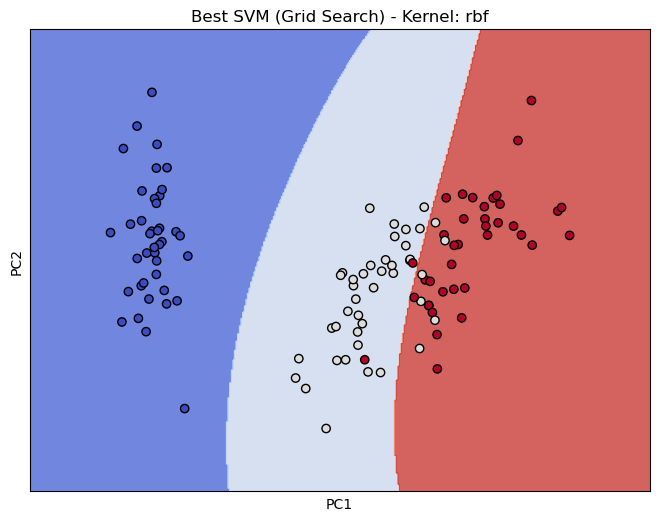

In [9]:
# Exercise 4: Grid search for best parameters
from sklearn.model_selection import GridSearchCV

print("\nExercise 4: Grid Search for optimal parameters")
print("This may take a moment...")

# Create base classifier
clf_grid = svm.SVC()

# Define parameter grid
c_values = np.logspace(-2, 2, 10)
gamma_values = np.logspace(-3, 1, 10)
param_grid = {
    'C': c_values,
    'gamma': gamma_values,
    'kernel': ['rbf', 'linear', 'poly']
}

# Perform grid search
grid = GridSearchCV(clf_grid, param_grid=param_grid, cv=5, n_jobs=-1, scoring='accuracy', verbose=1)
grid.fit(X_train_full, y_train_full)

print(f"\nBest parameters: {grid.best_params_}")
print(f"Best cross-validation score: {grid.best_score_:.3f}")
print(f"Test accuracy with best params: {grid.score(X_test_full, y_test_full):.3f}")

# Compare with previous best
print(f"\nPrevious best (without grid search): {best_model[1]:.3f}")
print(f"Grid search best: {grid.score(X_test_full, y_test_full):.3f}")
if grid.score(X_test_full, y_test_full) > best_model[1]:
    print("✓ Grid search improved the results!")
else:
    print("Grid search found similar or slightly different results.")

# Visualize if it's 2D
if grid.best_params_['kernel'] in ['rbf', 'linear']:
    # Train best model on PCA for visualization
    best_clf_pca = svm.SVC(**grid.best_params_)
    best_clf_pca.fit(X_train_pca, y_train)

    print(f"\nBest model on PCA: {best_clf_pca.score(X_test_pca, y_test):.3f}")

    plot_fit(X_train_pca, y_train, best_clf_pca)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title(f'Best SVM (Grid Search) - Kernel: {grid.best_params_["kernel"]}')
    plt.show()
